# Feature Engineering & Transformation

Geolocation enrichment, temporal + velocity features, scaling/encoding, and the SMOTE resampling demonstration. All logic is imported from `src`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


In [2]:
from src import config, data_loading, cleaning, geolocation, feature_engineering, preprocessing
df = cleaning.clean_fraud_data(data_loading.load_fraud_data())
print('clean shape:', df.shape)

clean shape: (151112, 11)


## 1. Geolocation: IP -> country (range lookup)
IPs are converted to integers, then matched to country ranges with a vectorised `merge_asof` + upper-bound validation (see `src.geolocation`).

In [3]:
ipc = data_loading.load_ip_country()
geo = geolocation.merge_ip_to_country(df, ipc)
print('matched to a country:', round((geo['country']!='Unknown').mean()*100, 1), '%')
geo[['ip_address','ip_int','country']].head()

matched to a country: 85.5 %


,ip_address,ip_int,country
0,7.327584e+08,732758368,Japan
1,3.503114e+08,350311387,United States
2,2.621474e+09,2621473820,United States
3,3.840542e+09,3840542443,Unknown
4,4.155831e+08,415583117,United States


,transactions,frauds,fraud_rate
country,,,
Luxembourg,72,28,38.889
Ecuador,106,28,26.415
Tunisia,118,31,26.271
Peru,119,31,26.050
Bolivia,53,13,24.528
Kuwait,90,21,23.333
Ireland,240,55,22.917
New Zealand,278,62,22.302
Lithuania,95,18,18.947


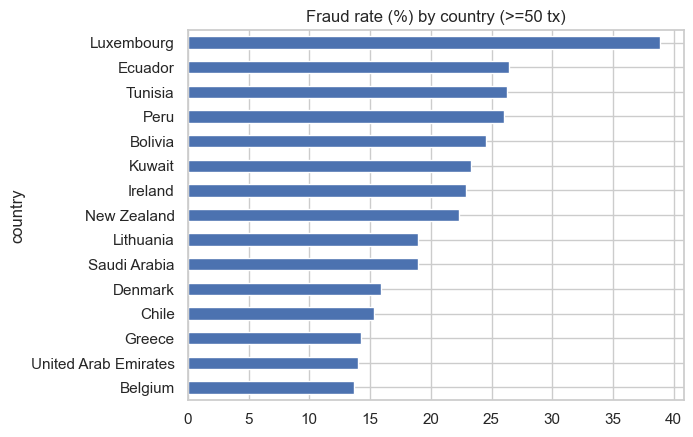

In [4]:
top = geolocation.fraud_rate_by_country(geo, config.FRAUD_TARGET, top_n=15)
display(top)
top['fraud_rate'].plot.barh(title='Fraud rate (%) by country (>=50 tx)'); plt.gca().invert_yaxis()
plt.savefig(config.FIGURES_DIR/'fraud_rate_by_country.png', dpi=120, bbox_inches='tight'); plt.show()

## 2. Temporal & velocity features
- `time_since_signup_hours` - gap between signup and purchase (key fraud signal).
- `hour_of_day`, `day_of_week` - when the purchase happened.
- `user_tx_count`, `device_tx_count`, `device_shared_users`, `sec_since_prev_user_tx` - velocity.

In [5]:
feat = feature_engineering.engineer_fraud_features(geo)
new_cols = ['hour_of_day','day_of_week','time_since_signup_hours','user_tx_count',
            'device_tx_count','device_shared_users','sec_since_prev_user_tx']
feat[new_cols + [config.FRAUD_TARGET]].head()

,hour_of_day,day_of_week,time_since_signup_hours,user_tx_count,device_tx_count,device_shared_users,sec_since_prev_user_tx,class
0,10,5,990.273333,1,1,1,31536000.0,0
1,21,5,2788.855278,1,1,1,31536000.0,0
2,11,3,1852.000278,1,1,1,31536000.0,0
3,23,2,103.136111,1,1,1,31536000.0,0
4,20,2,1286.523611,1,1,1,31536000.0,0


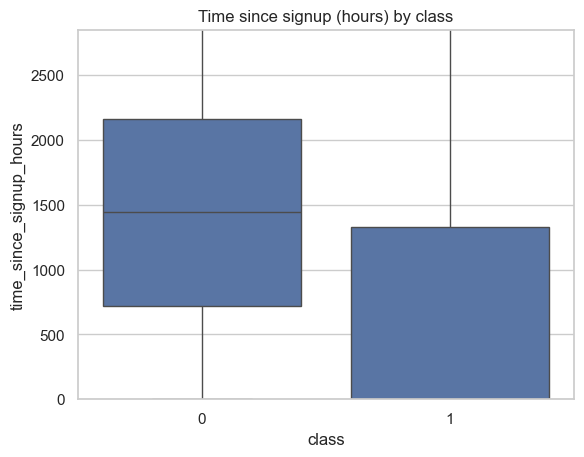

class
0    1443.030833
1       0.000278
Name: time_since_signup_hours, dtype: float64

In [6]:
ax = sns.boxplot(x=config.FRAUD_TARGET, y='time_since_signup_hours', data=feat)
ax.set_title('Time since signup (hours) by class'); ax.set_ylim(0, feat['time_since_signup_hours'].quantile(0.99))
plt.savefig(config.FIGURES_DIR/'time_since_signup_by_class.png', dpi=120, bbox_inches='tight'); plt.show()
feat.groupby(config.FRAUD_TARGET)['time_since_signup_hours'].median()

In [7]:
config.ensure_dirs()
feat.to_csv(config.PROCESSED_DIR/'fraud_data_processed.csv', index=False)
print('saved processed fraud data ->', config.PROCESSED_DIR/'fraud_data_processed.csv')

saved processed fraud data -> C:\Users\hp\Documents\fraud-detection\data\processed\fraud_data_processed.csv


### Also persist the cleaned credit-card data
The bank dataset needs no feature engineering (PCA features already), only de-duplication, so we save it here for the modelling notebook to consume.

In [8]:
cc = cleaning.clean_creditcard(data_loading.load_creditcard())
cc.to_csv(config.PROCESSED_DIR/'creditcard_processed.csv', index=False)
print('saved processed credit-card data ->', config.PROCESSED_DIR/'creditcard_processed.csv', cc.shape)

saved processed credit-card data -> C:\Users\hp\Documents\fraud-detection\data\processed\creditcard_processed.csv (283726, 31)


## 3. Transformation: scaling + one-hot encoding
A `ColumnTransformer` imputes + scales numerics and one-hot-encodes categoricals. It is **fit on training data only** inside the modelling pipeline.

In [9]:
X, y = preprocessing.select_fraud_model_columns(feat)
X_train, X_test, y_train, y_test = preprocessing.stratified_split(X, y)
pre = preprocessing.build_fraud_preprocessor(X_train)
Xt = pre.fit_transform(X_train)
print('transformed train matrix:', Xt.shape)
print('first 8 feature names:', list(pre.get_feature_names_out())[:8])

transformed train matrix: (120889, 199)
first 8 feature names: ['num__purchase_value', 'num__age', 'num__hour_of_day', 'num__day_of_week', 'num__time_since_signup_sec', 'num__time_since_signup_hours', 'num__user_tx_count', 'num__device_tx_count']


## 4. Class imbalance - SMOTE (training set only)
We oversample the minority class with **SMOTE** rather than undersample, because the fraud count is small in absolute terms and undersampling would discard most legitimate transactions (information loss). SMOTE is applied **only to the training fold** to avoid leaking synthetic samples into validation.

In [10]:
from imblearn.over_sampling import SMOTE
print('before SMOTE:', np.bincount(y_train))
Xr, yr = SMOTE(random_state=config.RANDOM_STATE).fit_resample(Xt, y_train)
print('after  SMOTE:', np.bincount(yr))

before SMOTE: [109568  11321]


after  SMOTE: [109568 109568]


### Resampling justification
| Aspect | Choice |
|---|---|
| Technique | **SMOTE** (synthetic oversampling) |
| Why not undersample | Fraud is rare in absolute count; undersampling throws away the majority of legit data |
| Leakage control | Applied inside the pipeline, **train fold only** |
| Alternative for credit-card | `scale_pos_weight` / `class_weight` also viable given extreme ratio |